In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

print("✓ Google Drive mounted!")

Mounted at /content/drive
✓ Google Drive mounted!


In [35]:
# ============================================
# AMES HOUSING DATASET - DATA CLEANING
# ============================================

# Import Libraries
import pandas as pd
import numpy as np

# Load Dataset
df = pd.read_csv("/content/drive/MyDrive/ML LAST LAB/AmesHousing.csv")

# Display Basic Information
print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
display(df.head())

# ============================================
# CHECK DATA TYPES
# ============================================

print("\nData Types:")
display(df.dtypes)

# ============================================
# CHECK MISSING VALUES
# ============================================

missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

print("\nMissing Values:")
display(missing_values)

# ============================================
# HANDLE MISSING VALUES
# ============================================

# ============================================
# HANDLE MISSING VALUES - AMES HOUSING
# ============================================

# -----------------------------
# 1. DROP COLUMNS WITH VERY HIGH MISSING VALUES
# -----------------------------
# These columns contain more than 80% missing values,
# so they provide little useful information.

high_missing_cols = [
    'Pool QC',
    'Misc Feature',
    'Alley',
    'Fence'
]

df.drop(columns=high_missing_cols, inplace=True)

# -----------------------------
# 2. FILL CATEGORICAL COLUMNS WITH "None"
# -----------------------------
# Missing values here usually mean the feature
# does not exist in the house (e.g., no garage,
# no basement, no fireplace).

none_cols = [
    'Mas Vnr Type',
    'Fireplace Qu',
    'Garage Type',
    'Garage Finish',
    'Garage Qual',
    'Garage Cond',
    'Bsmt Exposure',
    'BsmtFin Type 1',
    'BsmtFin Type 2',
    'Bsmt Qual',
    'Bsmt Cond'
]

for col in none_cols:
    df[col] = df[col].fillna('None')

# -----------------------------
# 3. FILL NUMERICAL COLUMNS WITH 0
# -----------------------------
# Missing values here usually indicate that
# the feature is absent (e.g., no garage area,
# no basement area, no masonry veneer).

zero_cols = [
    'Mas Vnr Area',
    'Bsmt Full Bath',
    'Bsmt Half Bath',
    'BsmtFin SF 1',
    'BsmtFin SF 2',
    'Total Bsmt SF',
    'Bsmt Unf SF',
    'Garage Area',
    'Garage Cars'
]

for col in zero_cols:
    df[col] = df[col].fillna(0)

# -----------------------------
# 4. FILL LOT FRONTAGE WITH MEDIAN
# -----------------------------
# Lot Frontage is an existing property feature.
# Missing values likely result from data collection issues.

df['Lot Frontage'] = df['Lot Frontage'].fillna(
    df['Lot Frontage'].median()
)

# -----------------------------
# 5. FILL GARAGE YEAR BUILT WITH 0
# -----------------------------
# If there is no garage, the construction year
# is not applicable.

df['Garage Yr Blt'] = df['Garage Yr Blt'].fillna(0)

# -----------------------------
# 6. FILL ELECTRICAL WITH MODE
# -----------------------------
# Only one value is missing, so the most common
# category is used.

df['Electrical'] = df['Electrical'].fillna(
    df['Electrical'].mode()[0]
)

# -----------------------------
# 7. VERIFY MISSING VALUES
# -----------------------------

print("Remaining Missing Values:")
print(df.isnull().sum().sum())

# Optional: display any columns that still contain missing values

remaining_missing = df.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0]

print("\nColumns Still Having Missing Values:")
print(remaining_missing)

# ============================================
# REMOVE DUPLICATES
# ============================================

duplicates = df.duplicated().sum()
print("\nDuplicate Rows:", duplicates)

df.drop_duplicates(inplace=True)

print("Shape After Removing Duplicates:", df.shape)

# ============================================
# CHECK OUTLIERS USING IQR METHOD
# ============================================

numeric_columns = df.select_dtypes(include=np.number).columns

for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

print("\nOutliers Capped Using IQR Method")

# ============================================
# CHECK DATASET SUMMARY
# ============================================

print("\nDataset Summary:")
display(df.describe())

# ============================================
# SAVE CLEANED DATASET
# ============================================

df.to_csv("ames_housing_cleaned.csv", index=False)

print("\nCleaned dataset saved as 'ames_housing_cleaned.csv'")

Dataset Shape: (2930, 82)

First 5 Rows:


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900



Data Types:


,0
Order,int64
PID,int64
MS SubClass,int64
MS Zoning,object
Lot Frontage,float64
...,...
Mo Sold,int64
Yr Sold,int64
Sale Type,object
Sale Condition,object



Missing Values:


,0
Pool QC,2917
Misc Feature,2824
Alley,2732
Fence,2358
Mas Vnr Type,1775
Fireplace Qu,1422
Lot Frontage,490
Garage Qual,159
Garage Cond,159
Garage Yr Blt,159


Remaining Missing Values:
0

Columns Still Having Missing Values:
Series([], dtype: int64)

Duplicate Rows: 0
Shape After Removing Duplicates: (2930, 78)

Outliers Capped Using IQR Method

Dataset Summary:


,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,...,2930.000000,2930.000000,2930.0,2930.0,2930.0,2930.0,2930.0,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,55.585324,68.415017,9559.384044,6.096246,5.537201,1971.371160,1984.266553,87.449019,...,91.086689,43.544027,0.0,0.0,0.0,0.0,0.0,6.216041,2007.790444,177082.283959
std,845.96247,1.887308e+08,37.943108,17.042927,3621.156578,1.406571,0.952158,30.200557,20.860286,132.861905,...,115.775439,53.445820,0.0,0.0,0.0,0.0,0.0,2.714492,1.316613,67906.837135
min,1.00000,5.263011e+08,20.000000,33.000000,1300.000000,2.000000,3.500000,1883.500000,1950.000000,0.000000,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,20.000000,60.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,...,0.000000,27.000000,0.0,0.0,0.0,0.0,0.0,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,70.000000,78.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,162.750000,...,168.000000,70.000000,0.0,0.0,0.0,0.0,0.0,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,145.000000,105.000000,17727.750000,10.000000,7.500000,2010.000000,2010.000000,406.875000,...,420.000000,175.000000,0.0,0.0,0.0,0.0,0.0,12.000000,2010.000000,339500.000000



Cleaned dataset saved as 'ames_housing_cleaned.csv'


In [36]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import numpy as np

X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

cat_cols = X.select_dtypes(include="object").columns
num_cols = X.select_dtypes(exclude="object").columns

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
], remainder="passthrough")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

reg_model = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestRegressor(n_estimators=200, random_state=42))
])

reg_model.fit(X_train, y_train)
pred = reg_model.predict(X_test)

print("REGRESSION RESULTS")
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
print("R2:", r2_score(y_test, pred))

REGRESSION RESULTS
RMSE: 18581.131918570856
R2: 0.935212753636103


In [37]:
X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

cat_cols = X.select_dtypes(include="object").columns
num_cols = X.select_dtypes(exclude="object").columns

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
], remainder="passthrough")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [38]:
reg_results = []

def eval_reg(model, name):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    reg_results.append([name, rmse, r2])

In [39]:
models_reg = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=10),
    "Lasso Regression": Lasso(alpha=0.001, max_iter=5000),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, random_state=42)
}

In [40]:
for name, model in models_reg.items():
    pipe = Pipeline([
        ("prep", preprocessor),
        ("model", model)
    ])
    eval_reg(pipe, name)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 327984821877.32965, tolerance: 1034995281.9612222
  model = cd_fast.sparse_enet_coordinate_descent(


In [41]:
reg_df = pd.DataFrame(reg_results, columns=["Model", "RMSE", "R2"])
reg_df.sort_values(by="R2", ascending=False)

,Model,RMSE,R2
4,Gradient Boosting,16281.671987,0.950256
3,Random Forest,18581.131919,0.935213
2,Lasso Regression,19264.831955,0.930357
0,Linear Regression,33504.653494,0.789353
1,Ridge Regression,70457.923297,0.068453


In [49]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error

In [50]:
cat_cols = X_train.select_dtypes(include="object").columns

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
], remainder="passthrough")

In [55]:
base_gb = GradientBoostingRegressor(random_state=42)

base_pipe = Pipeline([
    ("prep", preprocessor),
    ("model", base_gb)
])

base_pipe.fit(X_train, y_train)
base_pred = base_pipe.predict(X_test)

base_r2 = r2_score(y_test, base_pred)
base_rmse = np.sqrt(mean_squared_error(y_test, base_pred))

In [51]:
gb = GradientBoostingRegressor(random_state=42)

param_grid = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [3, 4]
}

In [52]:
pipe = Pipeline([
    ("prep", preprocessor),
    ("model", gb)
])

grid_gb = GridSearchCV(
    pipe,
    param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

grid_gb.fit(X_train, y_train)

print("BEST PARAMS:", grid_gb.best_params_)
print("BEST SCORE:", grid_gb.best_score_)

BEST PARAMS: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 200}
BEST SCORE: 0.919946257458859


In [53]:
best_model = grid_gb.best_estimator_

tuned_pred = best_model.predict(X_test)

tuned_r2 = r2_score(y_test, tuned_pred)
tuned_rmse = np.sqrt(mean_squared_error(y_test, tuned_pred))

In [56]:
compare_df = pd.DataFrame({
    "Model": ["Before Tuning", "After GridSearch Tuning"],
    "R2 Score": [base_r2, tuned_r2],
    "RMSE": [base_rmse, tuned_rmse]
})

compare_df

,Model,R2 Score,RMSE
0,Before Tuning,0.945533,17037.108534
1,After GridSearch Tuning,0.950256,16281.671987


In [ ]:
#CLASSIFICATION

In [57]:
df_clf = df.copy()

df_clf["Price_Category"] = pd.qcut(
    df_clf["SalePrice"],
    q=3,
    labels=["Low", "Medium", "High"]
)

Xc = df_clf.drop(["SalePrice", "Price_Category"], axis=1)
yc = df_clf["Price_Category"]

In [58]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

cat_cols = Xc.select_dtypes(include="object").columns
num_cols = Xc.select_dtypes(exclude="object").columns

preprocessor_clf = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("num", StandardScaler(), num_cols)
])

In [59]:
X_train, X_test, y_train, y_test = train_test_split(
    Xc, yc,
    test_size=0.2,
    random_state=42
)

In [60]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [61]:
from sklearn.metrics import accuracy_score

clf_results = []

def eval_clf(model, name):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)
    clf_results.append([name, acc])

In [62]:
models_clf = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=200),
    "Gradient Boosting": GradientBoostingClassifier(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier()
}

for name, model in models_clf.items():
    pipe = Pipeline([
        ("prep", preprocessor_clf),
        ("model", model)
    ])
    eval_clf(pipe, name)

In [63]:
import pandas as pd

clf_df = pd.DataFrame(clf_results, columns=["Model", "Accuracy"])
clf_df.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
2,Random Forest,0.889078
4,SVM,0.887372
0,Logistic Regression,0.877133
3,Gradient Boosting,0.860068
5,KNN,0.810580
1,Decision Tree,0.795222


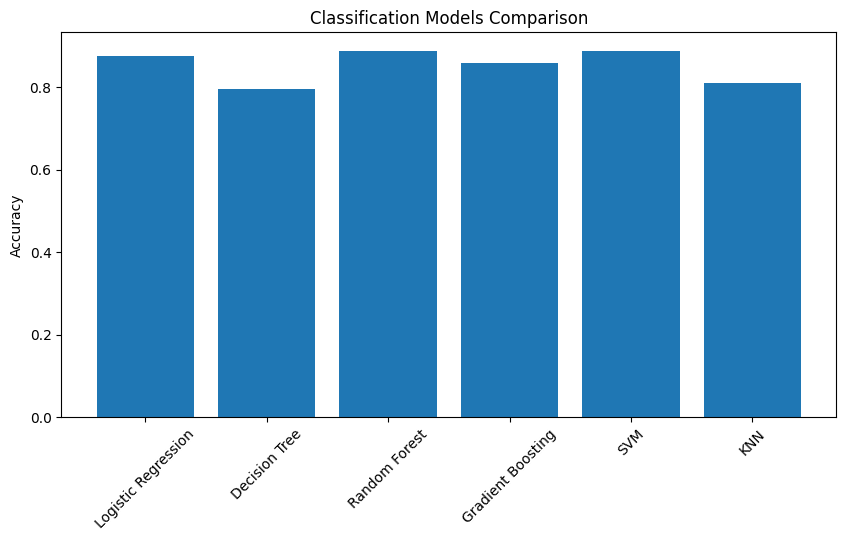

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(clf_df["Model"], clf_df["Accuracy"])
plt.xticks(rotation=45)
plt.title("Classification Models Comparison")
plt.ylabel("Accuracy")
plt.show()

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [66]:
def plot_conf_matrix(model, name):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    cm = confusion_matrix(y_test, pred, labels=["Low", "Medium", "High"])

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Low", "Medium", "High"],
                yticklabels=["Low", "Medium", "High"])

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

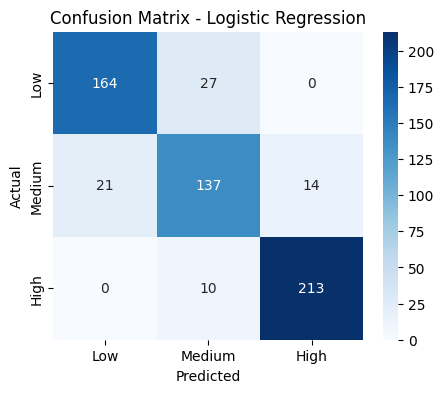

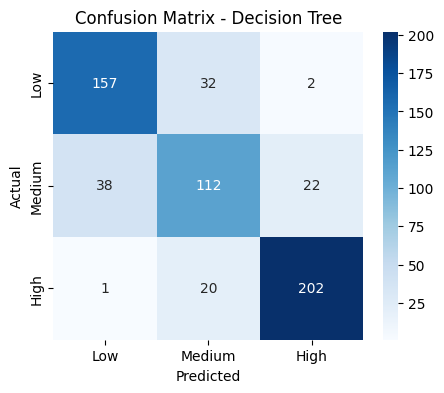

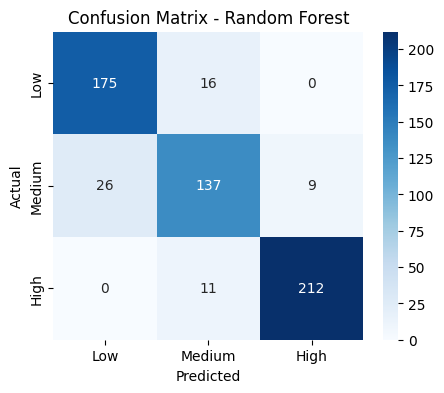

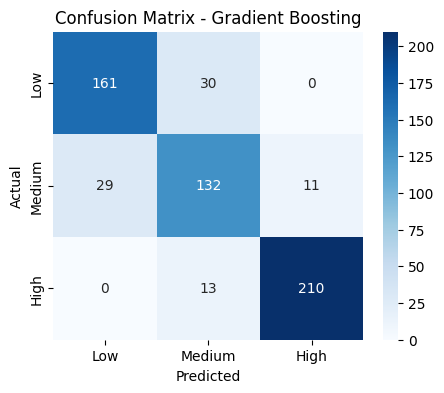

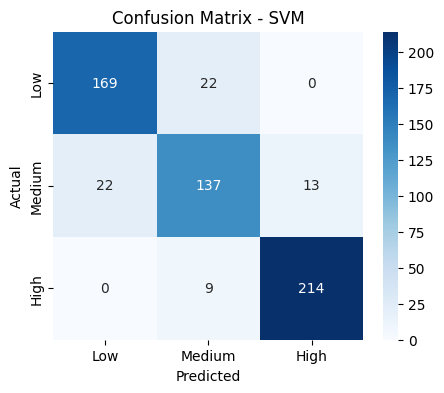

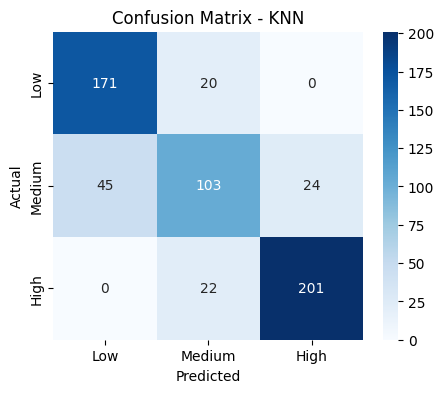

In [67]:
for name, model in models_clf.items():
    pipe = Pipeline([
        ("prep", preprocessor_clf),
        ("model", model)
    ])
    plot_conf_matrix(pipe, name)

In [73]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from scipy.stats import randint
from sklearn.metrics import accuracy_score

In [74]:
rf = RandomForestClassifier(random_state=42)

pipe_rf = Pipeline([
    ("prep", preprocessor_clf),
    ("model", rf)
])

In [75]:
param_dist = {
    "model__n_estimators": randint(100, 400),
    "model__max_depth": randint(5, 30),
    "model__min_samples_split": randint(2, 15),
    "model__min_samples_leaf": randint(1, 10),
    "model__max_features": ["sqrt", "log2"]
}

In [76]:
random_rf = RandomizedSearchCV(
    estimator=pipe_rf,
    param_distributions=param_dist,
    n_iter=20,        # 🔥 only 20 random combos (FAST)
    cv=3,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1,
    verbose=2
)

random_rf.fit(X_train, y_train)

print("🔥 BEST PARAMETERS:", random_rf.best_params_)
print("🔥 BEST CV SCORE:", random_rf.best_score_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
🔥 BEST PARAMETERS: {'model__max_depth': 19, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 149}
🔥 BEST CV SCORE: 0.8387382342571277


In [77]:
best_model = random_rf.best_estimator_

pred = best_model.predict(X_test)

acc = accuracy_score(y_test, pred)

print("🎯 FINAL TEST ACCURACY:", acc)

🎯 FINAL TEST ACCURACY: 0.8754266211604096


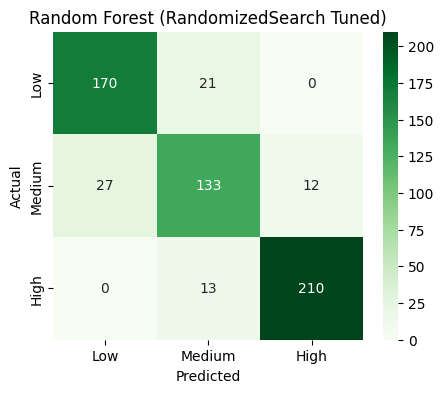

In [78]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred, labels=["Low", "Medium", "High"])

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Low", "Medium", "High"],
            yticklabels=["Low", "Medium", "High"])

plt.title("Random Forest (RandomizedSearch Tuned)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [79]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import Pipeline

best_gb = Pipeline([
    ("prep", preprocessor_reg),
    ("model", GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

best_gb.fit(X, y)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('prep',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  Index(['MS Zoning', 'Street', 'Lot Shape', 'Land Contour', 'Utilities',
       'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl',
       'Exterior 1st', 'Exterior 2nd',...
       'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure',
       'BsmtFin Type 1', 'BsmtFin Type 2', 'Heating', 'Heating QC',
       'Central Air', 'Electrical', 'Kitchen Qual', 'Functional',
       'Fireplace Qu', 'Garage Type', 'Garage Finish', 'Garage Qual',
       'Garage Cond', 'Paved Drive', 'Sale Type', 'Sale Condition'],
      dtype='object'))])),
                ('model',
                 GradientBoostingRegressor(learning_rate=0.05, n_estimators=200,
                                           random_state=42))])

In [80]:
def house_price_terminal():
    print("\n🏠 Welcome to House Price Predictor Terminal")
    print("Answer the following questions:\n")

    # IMPORTANT FEATURES (simple important ones)
    overall_qual = float(input("Overall Quality (1-10): "))
    gr_liv_area = float(input("Above Ground Living Area (sq ft): "))
    total_bsmt_sf = float(input("Basement Area (sq ft): "))
    garage_cars = float(input("Garage Cars (0-4): "))
    year_built = float(input("Year Built: "))
    full_bath = float(input("Full Bathrooms: "))

    # Create dataframe (model input format)
    input_data = pd.DataFrame([{
        "Overall Qual": overall_qual,
        "Gr Liv Area": gr_liv_area,
        "Total Bsmt SF": total_bsmt_sf,
        "Garage Cars": garage_cars,
        "Year Built": year_built,
        "Full Bath": full_bath
    }])

    # prediction
    pred = best_gb.predict(input_data)[0]

    print("\n🏡 Predicted House Price: $", round(pred, 2))

In [81]:
def house_price_terminal():
    print("\n🏠 Welcome to House Price Predictor Terminal")
    print("Answer the following questions:\n")

    # IMPORTANT FEATURES (simple important ones)
    overall_qual = float(input("Overall Quality (1-10): "))
    gr_liv_area = float(input("Above Ground Living Area (sq ft): "))
    total_bsmt_sf = float(input("Basement Area (sq ft): "))
    garage_cars = float(input("Garage Cars (0-4): "))
    year_built = float(input("Year Built: "))
    full_bath = float(input("Full Bathrooms: "))

    # Create dataframe (model input format)
    input_data = pd.DataFrame([{
        "Overall Qual": overall_qual,
        "Gr Liv Area": gr_liv_area,
        "Total Bsmt SF": total_bsmt_sf,
        "Garage Cars": garage_cars,
        "Year Built": year_built,
        "Full Bath": full_bath
    }])

    # prediction
    pred = best_gb.predict(input_data)[0]

    print("\n🏡 Predicted House Price: $", round(pred, 2))

In [ ]:
# --------------------------------------------------------------

# CLUSTERING

In [8]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

cluster_df = df.copy()

# Sirf numeric features use karte hain
cluster_data = cluster_df.select_dtypes(include=np.number)

# Scaling zaroori hai clustering ke liye
scaler = StandardScaler()
scaled_data = scaler.fit_transform(cluster_data)

In [9]:
kmeans = KMeans(n_clusters=3, random_state=42)
cluster_df["Cluster"] = kmeans.fit_predict(scaled_data)

print(cluster_df["Cluster"].value_counts())

Cluster
1    1407
0     926
2     597
Name: count, dtype: int64


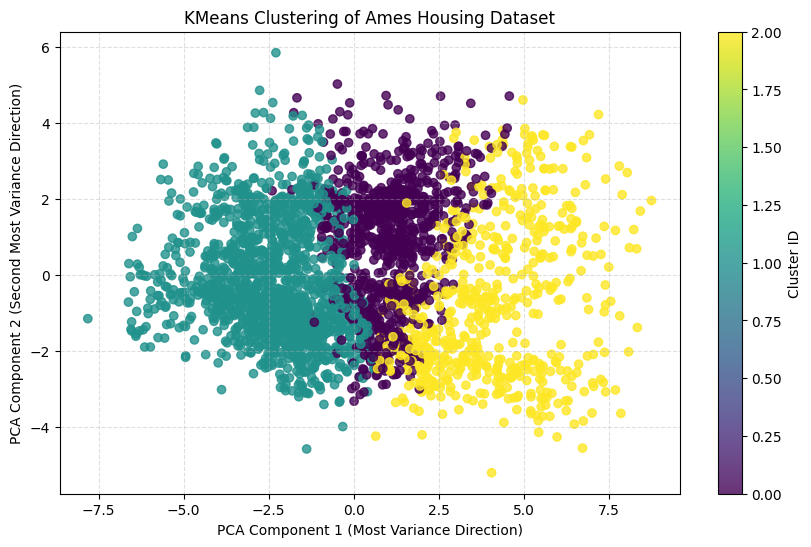

In [11]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# PCA reduction to 2D
pca = PCA(n_components=2)
components = pca.fit_transform(scaled_data)

# Add to dataframe
cluster_df["PCA1"] = components[:, 0]
cluster_df["PCA2"] = components[:, 1]

# Plot
plt.figure(figsize=(10,6))

plt.scatter(
    cluster_df["PCA1"],
    cluster_df["PCA2"],
    c=cluster_df["Cluster"],
    cmap="viridis",
    alpha=0.8
)

plt.title("KMeans Clustering of Ames Housing Dataset")
plt.xlabel("PCA Component 1 (Most Variance Direction)")
plt.ylabel("PCA Component 2 (Second Most Variance Direction)")

plt.colorbar(label="Cluster ID")

plt.grid(True, linestyle="--", alpha=0.4)

plt.show()